# U-Net for Coastal Segmentation

# ✨ Colab Settings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Alejandro-ZZ/coastal-segmentation/blob/master/Unet_workflow.ipynb)

In [ ]:
import os
from google.colab import drive

# Define the Google Drive paths
drive_dir = "/content/drive"
working_dir = f"{drive_dir}/MyDrive/coastal-segmentation"
drive.mount(drive_dir)

# Change the current working directory
assert os.path.exists(working_dir), f"Working directory not found: {working_dir}"
os.chdir(working_dir)
print("Current working dir:", os.getcwd())

In [ ]:
# GPU information
!nvidia-smi

Thu Aug  6 13:18:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# GPU current usage
!df -h /dev/shm

Filesystem      Size  Used Avail Use% Mounted on
shm             5.7G     0  5.7G   0% /dev/shm


# ✨ Project Config

In [ ]:
#@title ✔️ Imports


import gc
import json
import math
import matplotlib.pyplot as plt
import numpy
import skimage
from tqdm.auto import tqdm

from pathlib import Path
from pprint import pprint
from typing import Callable
from typing import Optional
from typing import List
from typing import Literal
from typing import Tuple

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import TensorBoard

print(f"""
Package versions

TensorFlow: {tf.__version__}
Numpy:      {numpy.__version__}
""")


Package versions

TensorFlow: 2.20.0
Numpy:      2.0.2



In [ ]:
#@title ✔️ Constants

# Project paths relative to the working directory
ANNOTATIONS_PATH = Path("assets/annotations/FRF_Duck")
SEGMENTATIONS_PATH = Path("results/segmentations/FRF_Duck")
TRAINING_PATH = Path("results/unet_training")
TENSOR_BOARD_PATH = TRAINING_PATH / "fit_logs"

# Keras native format (includes architecture + weights)
MODEL_CHECKPOINT_FILE = TRAINING_PATH / "FRF_Duck_Unet.keras"

# Expected image dimensions for the model input
# Resize images to 512x512 for training
INPUT_SIZE = 512

# Mapping array index represents the original class, value represents the new class
# Original --> 0:bg, 1:wetsand, 2:drysand, 3:veg, 4:heavies, 5:lag
#   Target --> 0:bg, 1:sand, 2:veg, 3:lag
CLASS_MAPPING = tf.constant(value=[0, 1, 1, 2, 1, 3], dtype=tf.int32)

# Training params
VALIDATION_SPLIT = 0.1
BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 200
NUM_CLASSES = 4     # 0: background, 1: sand, 2: vegetation, 3: lag
USE_LOGITS = True   # Whether the model outputs raw logits (True) or probabilities (False)

In [ ]:
# TODO: CHECK

# Use the ones defined in segmentation gym (doodleverse)
class_label_colormap = [
    '#3366CC','#DC3912','#FF9900','#109618','#990099','#0099C6','#DD4477',
    '#66AA00','#B82E2E', '#316395','#0d0887', '#46039f', '#7201a8', '#9c179e',
    '#bd3786', '#d8576b', '#ed7953', '#fb9f3a', '#fdca26', '#f0f921'
]
class_label_colormap = class_label_colormap[:NUM_CLASSES]

# Convert Hex strings to RGB tuples
def hex_to_rgb(hex_string):
    hex_string = hex_string.lstrip('#')
    return [int(hex_string[i:i+2], 16) for i in (0, 2, 4)]

# Create a lookup array. Shape: (NUM_CLASSES, 3)
COLORS_ARRAY = numpy.array([hex_to_rgb(c) for c in class_label_colormap], dtype=numpy.uint8)

# ✨ Definitions

Function and class definitions and implementations

In [ ]:
#@title ✔️ Utils


def process_and_segment(image_file: Path, model: tf.keras.Model) -> dict:
    """
    End-to-end pipeline: Load -> Preprocess -> Predict -> Postprocess
    """
    # Load image -----------------------------
    image = skimage.io.imread(image_file)
    original_h, original_w = image.shape[:2]

    # Resize image -----------------------------
    input_img = skimage.transform.resize(
        image=image,
        output_shape=(INPUT_SIZE, INPUT_SIZE),
        anti_aliasing=True
    )

    # Ensure the datatype matches the model's expectation (float32)
    # Shape: (INPUT_SIZE, INPUT_SIZE, 3)
    input_img = input_img.astype(numpy.float32)

    # Add the batch dimension
    # Shape: (1, INPUT_SIZE, INPUT_SIZE, 3)
    input_tensor = numpy.expand_dims(input_img, axis=0)

    # Make predictions
    # Shape: (1, INPUT_SIZE, INPUT_SIZE, num_classes)
    raw_predictions = model.predict(x=input_tensor, verbose=0)

    # Post-process predictions
    # Shape: (1, INPUT_SIZE, INPUT_SIZE)
    predicted_mask_downsampled = numpy.argmax(raw_predictions, axis=-1)

    # Remove the batch dimension
    # Shape: (INPUT_SIZE, INPUT_SIZE)
    predicted_mask_downsampled = predicted_mask_downsampled[0]

    # Restore original Size
    predicted_mask = skimage.transform.resize(
        image=predicted_mask_downsampled,
        output_shape=(original_h, original_w),
        order=0,                # equivalent of INTER_NEAREST.
        preserve_range=True,    # prevents from normalizing integer labels.
        anti_aliasing=False     # required when resizing categorical masks.
    )

    return {
        "image": image,
        "labels": predicted_mask,
        "color_labels": COLORS_ARRAY[predicted_mask],
        "low_image": input_img,
        "low_labels": predicted_mask_downsampled
    }


def plot_history_metric(
    history_data: dict,
    metric_name: str,
    ax,
    plot_lr: bool = False,
    start_epoch: int = 1
):
    # Calculate the 0-based starting index
    start_idx = max(0, start_epoch - 1)

    # Get and slice values to plot
    train_values = history_data[metric_name][start_idx:]
    val_values = history_data[f"val_{metric_name}"][start_idx:]

    # Generate matching epoch numbers for the x-axis
    epoch_values = range(start_epoch, start_epoch + len(train_values))

    # Plot main metrics
    line1 = ax.plot(epoch_values, train_values, label="Training")
    line2 = ax.plot(epoch_values, val_values, label="Validation")

    # Optional Learning Rate plotting
    if plot_lr:
        # Keras usually stores this as 'lr' or 'learning_rate'
        lr_values = history_data.get("lr", history_data.get("learning_rate"))

        if lr_values is not None:
            # Slice learning rate values to match the plotted epochs
            lr_values = lr_values[start_idx:]

            # Create a second y-axis sharing the same x-axis
            ax2 = ax.twinx()

            # Subtle styling: gray, dotted, low opacity
            line3 = ax2.plot(
                epoch_values, lr_values, ':',
                color="black", alpha=0.7, label="Learning Rate"
            )

            # Subdue the right Y-axis labels and ticks to match the line
            ax2.set_ylabel("Learning Rate", color='gray', alpha=0.6)
            ax2.tick_params(axis='y', colors='gray', labelcolor='gray')

            # Combine legends from both axes so they don't overlap awkwardly
            lines = line1 + line2 + line3
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc='best')
        else:
            print("Warning: Learning rate data not found in history.")
            ax.legend()
    else:
        ax.legend()

    ax.set_title(metric_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.grid()


In [ ]:
#@title ✔️ Data preparation


def get_data_paths(images_path: Path, labels_path: Path) -> Tuple[List[Path], List[Path]]:
    """
    Get sorted lists of image and label file paths, ensuring that each
    image has a corresponding label.

    Parameters
    ----------
    images_path : Path
        Directory containing the input images (JPG format).

    labels_path : Path
        Directory containing the corresponding label images (PNG format),
        named as "{image_stem}_label.png".

    Returns
    -------
    Tuple[List[Path], List[Path]]
        A tuple containing two lists:
        - List of valid image file paths (Path objects).
        - List of corresponding label file paths (Path objects).
    """
    # Get sorted list of JPG image files in the given images directory (images_path)
    image_files = sorted(images_path.glob("*.jpg"))

    # Output data file paths
    valid_image_files: List[Path] = []
    valid_label_files: List[Path] = []

    for image_file in image_files:
        # Create the label file path
        label_file = labels_path / f"{image_file.stem}_label.png"

        # Check if the label file exists
        if label_file.exists():
            valid_image_files.append(image_file)
            valid_label_files.append(label_file)
        else:
            raise ValueError(f"Label file not found. Image: {image_file}. Expected label: {label_file}")

    return valid_image_files, valid_label_files


def process_file(
        image_file: Path,
        mask_file: Path,
        one_hot_encode: bool = False,
        remap_classes: Optional[tf.Tensor] = None
) -> Tuple[tf.Tensor, tf.Tensor]:
    """Process a single image and its corresponding mask."""
    # Process image
    # Shape: (H, W, 3), dtype: float32, range: [0, 1]
    img = tf.io.read_file(image_file)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, size=[INPUT_SIZE, INPUT_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    # Process mask
    # Shape: (H, W, 1), dtype: int32, values: {0, 1, 2, 3} (after remapping)
    mask = tf.io.read_file(mask_file)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, size=[INPUT_SIZE, INPUT_SIZE], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.int32)

    # Remap classes
    if remap_classes is not None:
        mask = tf.gather(remap_classes, mask)

    # Optionally apply one-hot encoding to the mask if the model expects one-hot labels.
    if one_hot_encode:
        # Remove the trailing channel dimension: (H, W, 1) -> (H, W)
        mask = tf.squeeze(mask, axis=-1)

        # Apply one-hot encoding: (H, W) -> (H, W, NUM_CLASSES)
        mask = tf.one_hot(mask, depth=NUM_CLASSES)

    return img, mask

def create_dataset(
        image_files: List[Path],
        label_files: List[Path],
        map_func: Callable,
        batch_size: int,
        is_training: bool = False,
        one_hot_encode: bool = False,
        remap_classes: Optional[tf.Tensor] = None
) -> tf.data.Dataset:
    """
    Create a tf.data.Dataset from lists of image and label file paths.

    Parameters
    ----------
    image_files : List[Path]
        List of file paths to the input images.

    label_files : List[Path]
        List of file paths to the corresponding label images.

    map_func : Callable
        A function that takes an image file path and a label file path, processes them,
        and returns a tuple (image, label). This function will be applied to each pair
        of image and label file paths in the dataset.

        NOTE: both `one_hot_encode` and `remap_classes` are passed to `map_func` as keyword arguments.

    batch_size : int
        The number of samples per batch to load.

    is_training : bool, optional
        Whether the dataset is for training. If True, the dataset will be shuffled.

    one_hot_encode : bool, optional
        Whether to apply one-hot encoding to the labels. Note that the `map_func` must
        accept a `one_hot_encode` argument and handle the encoding accordingly.

    remap_classes : tf.Tensor, optional
        A 1D tensor that maps original class indices to new class indices. The index of the
        tensor represents the original class, and the value at that index represents the new class.
        For example, if the original classes are [0, 1, 2, 3, 4, 5] and we want to remap them to
        [0, 1, 1, 2, 1, 3], then remap_classes would be tf.constant([0, 1, 1, 2, 1, 3], dtype=tf.int32).
        Note that the `map_func` must accept a `remap_classes` argument.
    """
    # Need to be converted to string paths for tf.data.Dataset.from_tensor_slices
    image_files_str = [str(path) for path in image_files]
    label_files_str = [str(path) for path in label_files]

    # Map function wrapper to handle one-hot encoding and remapping if needed
    kwargs = {
        "one_hot_encode": one_hot_encode,
        "remap_classes": remap_classes
    }
    new_map_func = lambda img_file, label_file: map_func(
        img_file, label_file, one_hot_encode=one_hot_encode, remap_classes=remap_classes
    )

    # Create a dataset from the lists of image and label file paths
    dataset = tf.data.Dataset.from_tensor_slices((image_files_str, label_files_str))

    # Shuffle imagery for training only
    if is_training:
        dataset = dataset.shuffle(buffer_size=len(image_files))
    dataset = dataset.map(new_map_func, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


def create_train_val_datasets(metadata_file: Optional[Path] = None):
    # Get lists of image and label file paths
    image_files, label_files = get_data_paths(
        images_path=ANNOTATIONS_PATH / "train/images",
        labels_path=ANNOTATIONS_PATH / "train/labels"
    )

    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        image_files, label_files,
        test_size=VALIDATION_SPLIT,
        random_state=42
    )
    print(f"Total image-label pairs: {len(image_files)}")
    print(f"       Training samples: {len(X_train)}")
    print(f"     Validation samples: {len(X_val)}\n")

    # Metadata for training and validation datasets
    if metadata_file is not None:
        datasets_metadata = {
            "training": {
                "size": 1 - VALIDATION_SPLIT,
                "samples": len(X_train),
                "images": [str(path.name) for path in X_train],
                "labels": [str(path.name) for path in y_train],
            },
            "validation": {
                "size": VALIDATION_SPLIT,
                "samples": len(X_val),
                "images": [str(path.name) for path in X_val],
                "labels": [str(path.name) for path in y_val],
            }
        }
        metadata_file.parent.mkdir(parents=True, exist_ok=True)
        with open(metadata_file, "w") as f:
            json.dump(datasets_metadata, f, indent=4)

    # Create Datasets
    train_ds = create_dataset(
        image_files=X_train,
        label_files=y_train,
        map_func=process_file,
        batch_size=BATCH_SIZE,
        is_training=True,
        one_hot_encode=False,
        remap_classes=CLASS_MAPPING
    )
    val_ds = create_dataset(
        image_files=X_val,
        label_files=y_val,
        map_func=process_file,
        batch_size=BATCH_SIZE,
        is_training=False,
        one_hot_encode=False,
        remap_classes=CLASS_MAPPING
    )

    return train_ds, val_ds


In [ ]:
#@title ✔️ Unet architecture


def conv_block(x, num_filters: int, name: str):
    """
    Two 3×3 Conv2D + BatchNorm + ReLU.

    Alternatives:
        * Different activation (e.g. LeakyReLU)
    """
    # kernel_initializer
    #   * "he_normal": recommended when using ReLU and its variants (e.g., LeakyReLU, ELU).
    #   * "glorot_uniform": typically used with Sigmoid or Tanh activations.
    conv_kwargs = dict(
        filters=num_filters,
        kernel_size=3,
        strides=1,
        padding="same",
        activation=None,
        kernel_initializer="he_normal",
        use_bias=False, # Adding bias is redundant when using BatchNorm immediately after the Conv2D
    )

    x = layers.Conv2D(**conv_kwargs, name=f"{name}_Conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_BatchNorm1")(x)
    x = layers.Activation(activation="relu")(x)

    # Optional dropout here

    x = layers.Conv2D(**conv_kwargs, name=f"{name}_Conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_BatchNorm2")(x)
    x = layers.Activation("relu")(x)

    return x


def build_unet(
        input_shape: tuple,
        num_classes: int,
        base_filters: int = 64,
        depth: int = 4,
        dropout: float = 0.1,
        dropout_on_upsampling: bool = True,
        dropout_type: Literal["spatial", "standard"] = "spatial",
        output_activation: Literal[None, "softmax"] = "softmax"
) -> tf.keras.Model:
    """
    Standard UNet.

    Parameters
    ----------
    input_shape : tuple
        Model expected input shape. Example: (height, width, channels).

    num_classes  : int
        Number of output classes.

    base_filters : int, optional
        Filters in the first encoder block (doubles each level).
        Defaults to 64.

    depth : int, optional
        Number of encoder/decoder levels. Defaults to 4.

    dropout : float, optional
        Dropout rate applied in the bottleneck. Defaults to 0.1.

    dropout_on_upsampling : bool, optional
        If True (default), apply dropout in the decoder part of the network.

    dropout_type : str, optional
        Type of dropout to use. Possible values: "spatial" or "standard".

    output_activation : str, optional
        Activation function for the output layer.

        *   "softmax" for multi-class.

        *   "sigmoid" for binary or multi-label where an instance can
            belong to multiple classes (not the case here).

        *   None: logits. Standard practice is to feed raw logits into cross entropy loss
            (handling `from_logits=True`) for efficiency and stability.

    Returns
    -------
    tf.keras.Model
        Created keras model.
    """
    if output_activation not in [None, "softmax"]:
        raise ValueError(f"Output activation options: None, 'softmax'. Got: {output_activation}")

    if dropout_type == "spatial":
        dropout_layer = layers.SpatialDropout2D
    elif dropout_type == "standard":
        dropout_layer = layers.Dropout
    else:
        raise ValueError(f"Dropout type options: 'spatial', 'standard'. Got: {dropout_type}")


    # Logging messages
    print("-------  U-net Build Config  -------")
    print(f"          Input shape: {input_shape}")
    print(f"    Number of classes: {num_classes}")
    print(f"         Base filters: {base_filters}")
    print(f"                Depth: {depth}")
    print(f"              Dropout: {dropout} ({dropout_type})")
    print(f"Dropout on upsampling: {dropout_on_upsampling}")
    print(f"    Output activation: {output_activation}\n")


    inputs = layers.Input(shape=input_shape, name="image")
    x = inputs

    # Encoder
    skips = []
    for i in range(depth):
        x = conv_block(x, num_filters=base_filters * (2 ** i), name=f"enc{i}")
        skips.append(x)
        x = layers.MaxPooling2D(pool_size=2, name=f"pool{i}")(x)
        x = dropout_layer(dropout)(x)

    # Bottleneck
    x = conv_block(x, num_filters=base_filters * (2 ** depth), name="bottleneck")
    x = dropout_layer(dropout)(x)

    # Decoder
    for i in reversed(range(depth)):
        filters = base_filters * (2 ** i)
        x = layers.Conv2DTranspose(filters, kernel_size=2, strides=2, padding="same", name=f"up{i}")(x)
        x = layers.Concatenate(name=f"skip{i}")([x, skips[i]])
        if dropout_on_upsampling:
            x = dropout_layer(dropout)(x)
        x = conv_block(x, filters, name=f"dec{i}")

    # Output
    outputs = layers.Conv2D(num_classes, kernel_size=1, activation=output_activation, name="output_proba")(x)
    return Model(inputs, outputs, name="UNet")


In [ ]:
#@title ✔️ Custom Classes


class CustomMacroF1(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super(CustomMacroF1, self).__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.cm = self.add_weight(name="cm", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(tf.reshape(tf.argmax(y_pred, axis=-1), [-1]), tf.int32)
        cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=self.num_classes, dtype=tf.float32)
        self.cm.assign_add(cm)

    def result(self):
        diag = tf.linalg.diag_part(self.cm)
        row_sum = tf.reduce_sum(self.cm, axis=1)  # Actual
        col_sum = tf.reduce_sum(self.cm, axis=0)  # Predicted

        precision = tf.math.divide_no_nan(diag, col_sum)
        recall = tf.math.divide_no_nan(diag, row_sum)

        f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.cm.assign(tf.zeros((self.num_classes, self.num_classes)))

    # Required to save the parameters needed in "__init__"
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "num_classes": self.num_classes}


# ✨ Tensor Board

In [ ]:
#@title ✔️ Load extension

%load_ext tensorboard

In [ ]:
#@title ✔️ Kill

# Sometimes TensorBoard in Colab caches old runs or acts stubbornly if you restart runtimes. If it ever fails to load, you can kill existing background TensorBoard processes by running the following line. Then, rerun the %tensorboard magic command.

!kill $(ps -e | grep 'tensorboard' | awk '{print $1}')

In [ ]:
#@title ✔️ Launch

# Sometimes the inline TensorBoard viewer in Colab can feel cramped or freeze if the notebook idles. If you prefer a full-screen experience, you can click the "Launch TensorBoard in a new window" icon (it looks like a small box with an arrow popping out) located in the top-right corner of the TensorBoard widget cell.


# Launch TensorBoard
print(f"!! TensorBoard logs dir: {TENSOR_BOARD_PATH}")
print()
%tensorboard --logdir {TENSOR_BOARD_PATH}

# ✨ Training

In [ ]:
#@title ✔️ GPU config


# Enable GPU Memory Growth (Prevents TF from allocating all VRAM at once)
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    try:
        for gpu_device in gpu_devices:
            tf.config.experimental.set_memory_growth(device=gpu_device, enable=True)
        print(f"GPU enabled: {gpu_devices}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPU found. Training on CPU.")


# "mixed_float16" policy allows the model to use float16 precision for computations
# while keeping certain variables (like batch normalization) in float32 for stability.
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Global policy:", tf.keras.mixed_precision.global_policy())

Error setting GPU memory growth: Physical devices cannot be modified after being initialized
Global policy: <DTypePolicy "mixed_float16">


In [ ]:
#@title ✔️ Datasets creation
train_dataset, val_dataset = create_train_val_datasets(
    metadata_file=TRAINING_PATH / "datasets_metadata.json"
)

Total 107 valid image-label pairs.
Training: 96 samples
Validation: 11 samples.


In [ ]:
#@title ✔️ Model build


train_model = build_unet(
    input_shape=(INPUT_SIZE, INPUT_SIZE, 3),
    num_classes=NUM_CLASSES,
    base_filters=16,
    dropout=0.1,
    output_activation="softmax" if not USE_LOGITS else None,
)

# Loss options: Dice Loss, Focal Loss
train_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=USE_LOGITS),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
        CustomMacroF1(num_classes=NUM_CLASSES)
        # CustomMeanIoU(num_classes=NUM_CLASSES),
    ]
)


# model.summary()
print("-------  MODEL INFO  -------")
print("        Name:", train_model.name)
print(" Input shape:", train_model.input_shape)
print("Output shape:", train_model.output_shape)
print("Total params:", train_model.count_params())


-------  U-net Build Config  -------
          Input shape: (512, 512, 3)
    Number of classes: 4
         Base filters: 16
                Depth: 4
              Dropout: 0.1 (spatial)
Dropout on upsampling: True
    Output activation: None

-------  MODEL INFO  -------
        Name: UNet
 Input shape: (None, 512, 512, 3)
Output shape: (None, 512, 512, 4)
Total params: 1945572


In [ ]:
#@title ✔️ Model fit


# Clear the Keras session to release memory
# Force Python's garbage collector to run
tf.keras.backend.clear_session()
gc.collect()

# Callbacks
callbacks = [
    ModelCheckpoint(
        filepath=MODEL_CHECKPOINT_FILE,
        monitor="val_loss",
        verbose=0,
        save_best_only=True,
        mode="min"
    ),

    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=30,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=15,
        min_lr=1e-7
    ),
]

# !! Run TensorBoard with: tensorboard --logdir=results/unet_training/fit_logs

# Train Model
print("Starting training...")
history = train_model.fit(
    x=train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    verbose=1,
    callbacks=callbacks
)

# save history
history_file = TRAINING_PATH / "training_history.json"
with open(history_file, "w") as f:
    json.dump(history.history, f, indent=4)
print("\nTraining complete")

Starting training...
Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 32s 978ms/step - acc: 0.3895 - loss: 1.3812 - macro_f1: 0.2675 - val_acc: 0.4035 - val_loss: 9.5198 - val_macro_f1: 0.1810 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step - acc: 0.6303 - loss: 1.0153 - macro_f1: 0.5077 - val_acc: 0.3562 - val_loss: 11.6843 - val_macro_f1: 0.1610 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - acc: 0.7723 - loss: 0.8242 - macro_f1: 0.6058 - val_acc: 0.2882 - val_loss: 24.0294 - val_macro_f1: 0.1656 - learning_rate: 0.0010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - acc: 0.8203 - loss: 0.7159 - macro_f1: 0.6279 - val_acc: 0.3189 - val_loss: 8.7203 - val_macro_f1: 0.2570 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 338ms/step - acc: 0.8358 - loss: 0.6594 - macro_f1: 0.6339 - val_acc: 0.4023 - val_loss: 2.2548 - val_macro_f1: 0.2782 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - acc: 0.8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - acc: 0.9244 - loss: 0.2221 - macro_f1: 0.8148


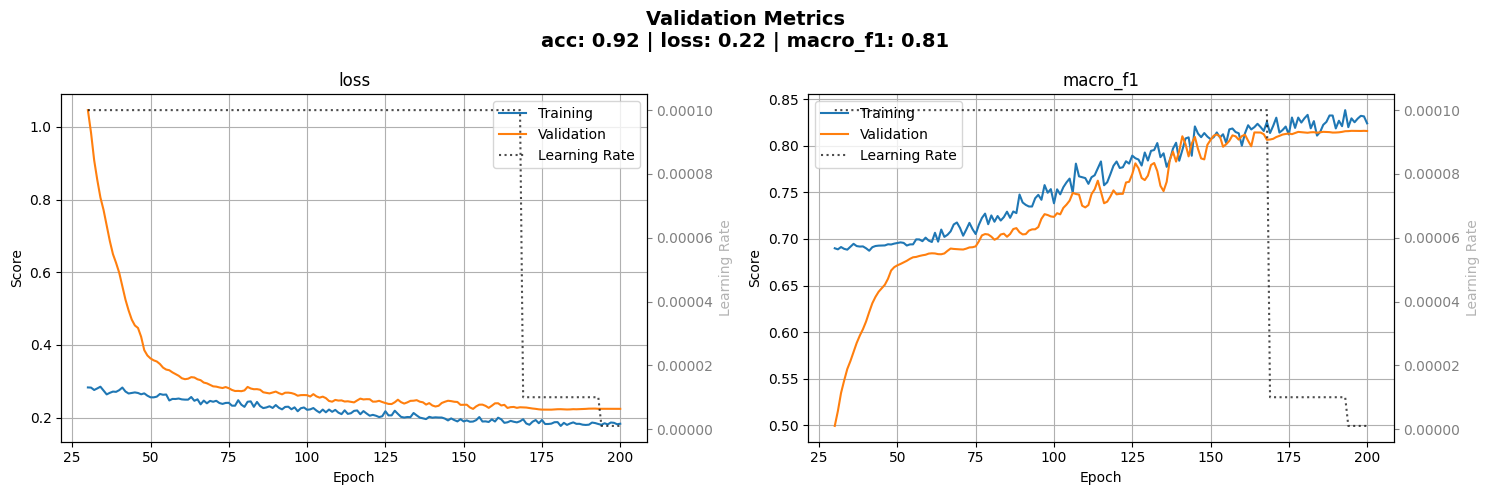

In [ ]:
#@title ✔️ Training Report

# Evaluate model ---------------------------
eval_scores = train_model.evaluate(
    x=val_dataset,
    verbose=0,
    return_dict=True
)
metrics_text = " | ".join([
    f"{name}: {score:.2f}"
    for name, score in eval_scores.items()
])


# Plot metrics ---------------------------
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
ax1, ax2 = axs

plot_history_metric(history.history, "loss", ax1, plot_lr=True, start_epoch=30)
plot_history_metric(history.history, "macro_f1", ax2, plot_lr=True, start_epoch=30)

plt.suptitle(f"Validation Metrics\n{metrics_text}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
#@title ✔️ Test Evaluation


# Load the model
model = tf.keras.models.load_model(
    filepath=MODEL_CHECKPOINT_FILE,
    custom_objects={'CustomMacroF1': CustomMacroF1}
)


test_dirs = ["train", "test_c1", "test_c6"]

for test_dir in test_dirs:
    # Get lists of image and label file paths
    image_files, label_files = get_data_paths(
        images_path=ANNOTATIONS_PATH / f"{test_dir}/images",
        labels_path=ANNOTATIONS_PATH / f"{test_dir}/labels"
    )

    # Create Datasets
    # Remapping is only needed in the annotated labels for train subset.
    # Test data already have 4 classes only
    test_ds = create_dataset(
        image_files=image_files,
        label_files=label_files,
        map_func=process_file,
        batch_size=BATCH_SIZE,
        is_training=False,
        one_hot_encode=False,
        remap_classes=CLASS_MAPPING if test_dir == "train" else None
    )

    # Evaluate model
    print(f"--------  {test_dir}  --------")
    test_scores = model.evaluate(x=test_ds, verbose=1, return_dict=True)
    for metric_name, metric_score in test_scores.items():
        print(f"  * {metric_name}: {metric_score:.4f}")
    print()

--------  train  --------
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 415ms/step - acc: 0.9439 - loss: 0.1714 - macro_f1: 0.8277
  * acc: 0.9439
  * loss: 0.1714
  * macro_f1: 0.8277

--------  test_c1  --------
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.9471 - loss: 0.1642 - macro_f1: 0.8408
  * acc: 0.9471
  * loss: 0.1642
  * macro_f1: 0.8408

--------  test_c6  --------
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step - acc: 0.9234 - loss: 0.2410 - macro_f1: 0.7592
  * acc: 0.9234
  * loss: 0.2410
  * macro_f1: 0.7592



# ✨ Inference Pipeline

In [ ]:
#@title ✔️ Segment Images

test_dirs = ["train", "test_c1", "test_c6"]

# Load the model
model = tf.keras.models.load_model(
    filepath=MODEL_CHECKPOINT_FILE,
    custom_objects={"CustomMacroF1": CustomMacroF1}
)


for test_dir in test_dirs:
    # Create results directory
    test_path = SEGMENTATIONS_PATH / f"{test_dir}/unet"
    color_path = test_path / "color_labels"
    color_path.mkdir(parents=True, exist_ok=True)

    # Get lists of image and label file paths
    # Labels are not needed as we will only predict on input images
    image_files, _ = get_data_paths(
        images_path=ANNOTATIONS_PATH / f"{test_dir}/images",
        labels_path=ANNOTATIONS_PATH / f"{test_dir}/labels"
    )

    files_iter = tqdm(zip(image_files, _), desc=f"Processing '{test_dir}'")
    for image_file, _ in files_iter:
        # Process and segment the image
        segment_results = process_and_segment(image_file, model)

        # Save as NPZ
        npz_file = test_path / f"{image_file.stem}.npz"
        numpy.savez(file=npz_file, **segment_results)

        # Save color labels
        png_file = color_path / f"{image_file.stem}.png"
        skimage.io.imsave(fname=png_file, arr=segment_results["color_labels"])

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 130 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Processing 'train': 0it [00:00, ?it/s]

Processing 'test_c1': 0it [00:00, ?it/s]

Processing 'test_c6': 0it [00:00, ?it/s]

## ✔️ Visualize Output

In [ ]:
# Read NPZ file with segmentation results
npz_file = SEGMENTATIONS_PATH / f"test_c1/unet/FRF_c1_snap_20210520160000_EBG.npz"
npz_data = numpy.load(file=npz_file)
npz_data.files

['image', 'labels', 'color_labels', 'low_image', 'low_labels']

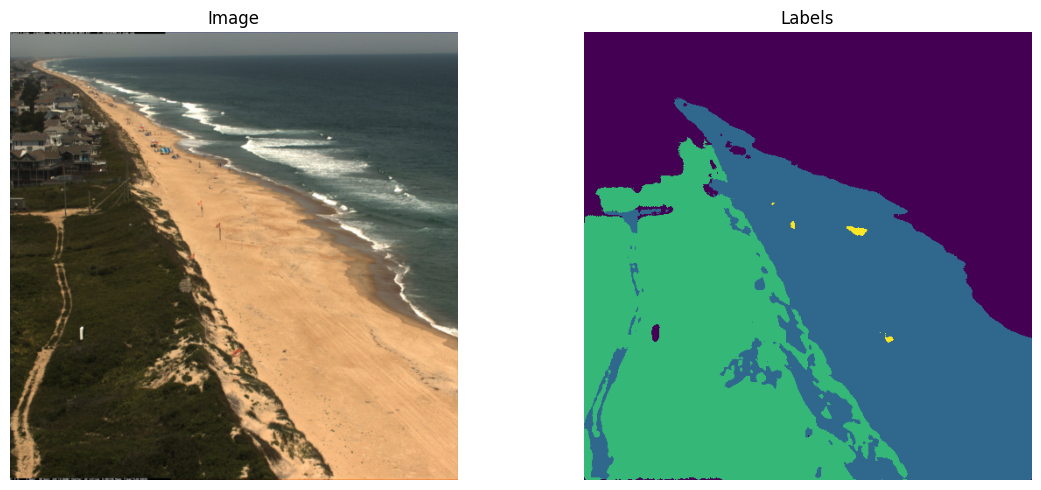

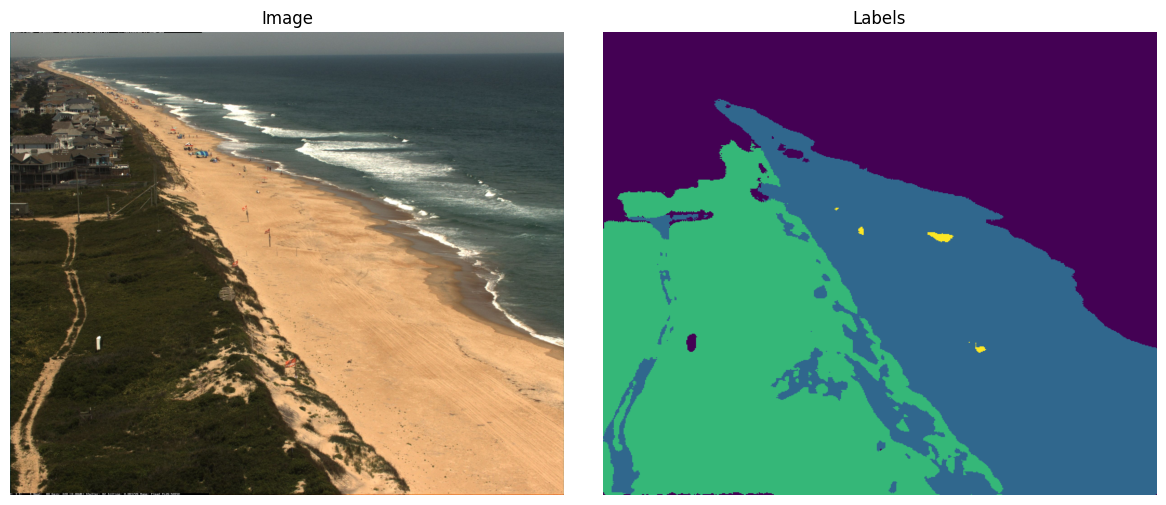

In [ ]:
# Visualize the original and low-resolution image and mask

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axs

ax1.imshow(npz_data["low_image"])
ax1.set_title("Image")
ax1.axis("off")
ax2.imshow(npz_data["low_labels"])
ax2.set_title("Labels")
ax2.axis("off")

plt.tight_layout()
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axs

ax1.imshow(npz_data["image"])
ax1.set_title("Image")
ax1.axis("off")
ax2.imshow(npz_data["labels"])
ax2.set_title("Labels")
ax2.axis("off")

plt.tight_layout()
plt.show()